# Census 2020 profiling — urban AGEBs of Mexico City

This notebook profiles the INEGI *Censo de Población y Vivienda 2020 — Principales resultados por AGEB y manzana urbana* file for Mexico City (state `09`), the demographic layer of the warehouse. It explains the row hierarchy of the file, isolates the urban AGEB rows, quantifies confidentiality suppression (`*`) and missing values (`N/D`) in the variables the demographic KPIs need, shows their distributions, and reconciles the AGEB population with the state and alcaldía totals.

The raw file is a read-only input: every column is read as text so that INEGI's codes (`*`, `N/D`, leading zeros in keys) are seen exactly as published. Nothing is written to disk.

In [1]:
from pathlib import Path
import sys

ROOT = next((parent for parent in (Path.cwd(), *Path.cwd().parents) if (parent / "src" / "config.py").exists()), None)
if ROOT is None:
    raise RuntimeError("Could not locate the repository root from the notebook working directory")
sys.path.insert(0, str(ROOT))

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from src.config import CITY_LOC, CVE_ENT, DATA_RAW

CENSUS_DIR = DATA_RAW / "census_ageb_2020_09" / "ageb_mza_urbana_09_cpv2020"
CENSUS_PATH = CENSUS_DIR / "conjunto_de_datos" / "conjunto_de_datos_ageb_urbana_09_cpv2020.csv"
DICTIONARY_PATH = CENSUS_DIR / "diccionario_de_datos" / "diccionario_datos_ageb_urbana_09_cpv2020.csv"
AGEB_POLYGONS_PATH = DATA_RAW / "marco_geo_2020_09" / "conjunto_de_datos" / "09a.shp"

assert all(path.exists() for path in (CENSUS_PATH, DICTIONARY_PATH, AGEB_POLYGONS_PATH))

# dtype=str + keep_default_na=False keeps '*', 'N/D' and the zero-padded keys exactly as published.
census = pd.read_csv(CENSUS_PATH, dtype=str, encoding="utf-8-sig", keep_default_na=False)
print(f"{len(census):,} rows x {census.shape[1]} columns")
census[["ENTIDAD", "NOM_ENT", "MUN", "NOM_MUN", "LOC", "NOM_LOC", "AGEB", "MZA", "POBTOT"]].head(6)

68,941 rows x 230 columns


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,AGEB,MZA,POBTOT
0,09,Ciudad de México,000,Total de la entidad Ciudad de México,0000,Total de la entidad,0000,000,9209944
1,09,Ciudad de México,002,Azcapotzalco,0000,Total del municipio,0000,000,432205
2,09,Ciudad de México,002,Azcapotzalco,0001,Total de la localidad urbana,0000,000,432205
3,09,Ciudad de México,002,Azcapotzalco,0001,Total AGEB urbana,0010,000,3183
4,09,Ciudad de México,002,Azcapotzalco,0001,Azcapotzalco,0010,001,159
5,09,Ciudad de México,002,Azcapotzalco,0001,Azcapotzalco,0010,002,145


## 1. File structure: one file, five levels of aggregation

The file mixes rows of different grain. The geographic keys tell them apart; a level is marked by the *first* key set to its "total" code:

| Level | Rule | Meaning |
|---|---|---|
| State total | `MUN = '000'` | Whole of Mexico City (includes rural population) |
| Municipality (alcaldía) total | `LOC = '0000'` | One row per alcaldía (includes its rural localities) |
| Locality total | `AGEB = '0000'` | One row per *urban* locality |
| **AGEB total** | **`MZA = '000'`** | **One row per urban AGEB — the grain of the warehouse** |
| Block | `MZA <> '000'` | One row per urban block (heavily suppressed for confidentiality) |

Summing the file without filtering would count each resident up to five times.

In [2]:
def row_level(df: pd.DataFrame) -> pd.Series:
    """Classify each census row by its aggregation level (most aggregated rule wins)."""
    level = pd.Series("Block", index=df.index)
    level[df["MZA"].eq("000")] = "AGEB total"
    level[df["AGEB"].eq("0000")] = "Locality total"
    level[df["LOC"].eq("0000")] = "Municipality total"
    level[df["MUN"].eq("000")] = "State total"
    return level


census["level"] = row_level(census)
level_order = ["State total", "Municipality total", "Locality total", "AGEB total", "Block"]
structure = (
    census.groupby("level")
    .agg(rows=("POBTOT", "size"), pobtot_as_published=("POBTOT", lambda s: pd.to_numeric(s, errors="coerce").sum()))
    .reindex(level_order)
)
structure["pobtot_as_published"] = structure["pobtot_as_published"].astype("int64")
assert census["ENTIDAD"].eq(CVE_ENT).all()
assert structure.loc["State total", "rows"] == 1
assert structure.loc["Municipality total", "rows"] == 16
structure

,rows,pobtot_as_published
level,,
State total,1,9209944
Municipality total,16,9209944
Locality total,35,9145632
AGEB total,2433,9145632
Block,66456,9145590


The levels are nested totals, not separate records: the 16 alcaldía rows add up exactly to the state row (9,209,944), and the urban locality rows add up exactly to the AGEB rows (9,145,632). The gap between the two is the rural population, which has no AGEB breakdown (§6). Block rows add up to 42 residents fewer than the AGEB rows. They are not used, so the **AGEB total row is the authoritative source** for each AGEB.

## 2. Urban AGEB rows and the shared key `CVEGEO`

The warehouse key is the 13-character `CVEGEO = ENTIDAD (2) + MUN (3) + LOC (4) + AGEB (4)`, the same identifier used by the INEGI Marco Geoestadístico 2020 polygons (`09a.shp`).

In [3]:
ageb = census.loc[census["level"].eq("AGEB total")].copy()
ageb["cvegeo"] = ageb["ENTIDAD"] + ageb["MUN"] + ageb["LOC"] + ageb["AGEB"]
ageb["is_city_core"] = ageb["LOC"].eq(CITY_LOC)

assert len(ageb) == 2_433
assert ageb["cvegeo"].is_unique
assert ageb["cvegeo"].str.len().eq(13).all()

polygon_keys = set(gpd.read_file(AGEB_POLYGONS_PATH, ignore_geometry=True)["CVEGEO"].astype(str))
ageb["has_polygon"] = ageb["cvegeo"].isin(polygon_keys)
ageb["pop_total"] = pd.to_numeric(ageb["POBTOT"]).astype("int64")

without_polygon = ageb.loc[~ageb["has_polygon"], ["cvegeo", "NOM_MUN", "NOM_LOC", "pop_total"]]
print(f"Census AGEB rows: {len(ageb):,}  |  polygons in 09a.shp: {len(polygon_keys):,}")
print(f"AGEB rows with a polygon: {int(ageb['has_polygon'].sum()):,}  |  without: {len(without_polygon)}")
print(f"Polygons without a census row: {len(polygon_keys - set(ageb['cvegeo']))}")
without_polygon

Census AGEB rows: 2,433  |  polygons in 09a.shp: 2,431
AGEB rows with a polygon: 2,431  |  without: 2
Polygons without a census row: 0


,cvegeo,NOM_MUN,NOM_LOC,pop_total
48557,0901101101107,Tláhuac,Total AGEB urbana,3050
53813,0901201351227,Tlalpan,Total AGEB urbana,4058


Two census AGEBs have no polygon in the 2020 geostatistical frame, so they cannot be mapped or joined to points. They will be **dropped and counted** in `src/transform/census.py`; every other polygon has exactly one census row. From here on the profile uses the **2,431 AGEBs with a polygon**, the population the warehouse will hold.

In [4]:
assert sorted(without_polygon["cvegeo"]) == ["0901101101107", "0901201351227"]
assert int(without_polygon["pop_total"].sum()) == 7_108
assert len(polygon_keys - set(ageb["cvegeo"])) == 0

urban = ageb.loc[ageb["has_polygon"]].copy()
assert len(urban) == 2_431
print(f"Urban AGEBs kept: {len(urban):,} ({int(urban['is_city_core'].sum()):,} in the main locality '{CITY_LOC}' "
      f"of their alcaldía, {int((~urban['is_city_core']).sum())} in other urban localities)")

Urban AGEBs kept: 2,431 (2,348 in the main locality '0001' of their alcaldía, 83 in other urban localities)


## 3. Variables needed by the warehouse: suppression, missing values and zeros

INEGI suppresses values with `*` when publishing them could identify a household (AGEBs or blocks with very few dwellings or residents), and uses `N/D` when the value is not available. Neither means zero, so the transform will store both as `NULL` and count them per AGEB in `n_suppressed_fields`. The table covers every source variable of `dw.fact_census_ageb`.

In [5]:
FACT_COLUMNS = {
    "POBTOT": "pop_total", "POBFEM": "pop_female", "POBMAS": "pop_male",
    "POB0_14": "pop_0_14", "POB15_64": "pop_15_64", "POB65_MAS": "pop_65_plus",
    "P_12YMAS": "pop_12_plus", "P_18YMAS": "pop_18_plus", "P_60YMAS": "pop_60_plus",
    "PEA": "pea", "PEA_F": "pea_female", "PEA_M": "pea_male", "PE_INAC": "pop_inactive",
    "POCUPADA": "pop_employed", "PDESOCUP": "pop_unemployed", "GRAPROES": "avg_schooling",
    "TOTHOG": "households", "VIVTOT": "dwellings_total", "TVIVHAB": "dwellings_inhabited",
    "PROM_OCUP": "avg_occupants",
}
assert set(FACT_COLUMNS).issubset(census.columns)

values = urban[list(FACT_COLUMNS)]
numeric = values.apply(pd.to_numeric, errors="coerce")
unexpected = numeric.isna() & ~values.isin(["*", "N/D"])
assert not unexpected.any().any(), f"Unexpected non-numeric codes: {set(values.where(unexpected).stack().dropna())}"

quality = pd.DataFrame({
    "dw_column": pd.Series(FACT_COLUMNS),
    "suppressed_*": values.eq("*").sum(),
    "not_available_N/D": values.eq("N/D").sum(),
    "empty": values.eq("").sum(),
    "zeros": numeric.eq(0).sum(),
    "valid": numeric.notna().sum(),
    "min": numeric.min(),
    "median": numeric.median(),
    "max": numeric.max(),
})
quality["pct_null_after_cleaning"] = (100 * (quality["suppressed_*"] + quality["not_available_N/D"]) / len(urban)).round(2)
quality

,dw_column,suppressed_*,not_available_N/D,empty,zeros,valid,min,median,max,pct_null_after_cleaning
POBTOT,pop_total,0,0,0,17,2431,0.0,3396.0,21198.00,0.00
POBFEM,pop_female,10,0,0,18,2421,0.0,1783.0,11128.00,0.41
POBMAS,pop_male,10,0,0,17,2421,0.0,1616.0,10616.00,0.41
POB0_14,pop_0_14,18,0,0,21,2413,0.0,565.0,3701.00,0.74
POB15_64,pop_15_64,10,0,0,17,2421,0.0,2401.0,16887.00,0.41
POB65_MAS,pop_65_plus,22,0,0,20,2409,0.0,400.0,1825.00,0.90
P_12YMAS,pop_12_plus,10,0,0,17,2421,0.0,2916.0,18524.00,0.41
P_18YMAS,pop_18_plus,10,0,0,17,2421,0.0,2669.0,17180.00,0.41
P_60YMAS,pop_60_plus,17,0,0,18,2414,0.0,582.5,2703.00,0.70
PEA,pea,10,0,0,18,2421,0.0,1867.0,13648.00,0.41


In [6]:
urban["n_suppressed_fields"] = values.isin(["*", "N/D"]).sum(axis=1)
suppressed_rows = urban.loc[urban["n_suppressed_fields"].gt(0)]
print(f"AGEBs with at least one suppressed field: {len(suppressed_rows)} of {len(urban):,}")
print(f"Population living in them: {int(suppressed_rows['pop_total'].sum()):,} "
      f"({100 * suppressed_rows['pop_total'].sum() / urban['pop_total'].sum():.3f} % of the urban total)")
print("Distribution of n_suppressed_fields:", urban["n_suppressed_fields"].value_counts().sort_index().to_dict())
suppressed_rows.groupby(pd.cut(suppressed_rows["pop_total"], [-1, 0, 9, 99, 999, 10**6])).size().rename("AGEBs by pop_total")

AGEBs with at least one suppressed field: 73 of 2,431
Population living in them: 27,768 (0.304 % of the urban total)
Distribution of n_suppressed_fields: {0: 2358, 1: 54, 2: 3, 3: 5, 4: 1, 17: 10}


pop_total
(0, 9]             9
(9, 99]           23
(99, 999]         32
(999, 1000000]     9
Name: AGEBs by pop_total, dtype: int64

Findings:

- `POBTOT`, `VIVTOT` and `TVIVHAB` are never suppressed, so **population and density are computable for every AGEB**.
- Only 73 AGEBs (0.30 % of the urban population) have any suppressed field. Heavy suppression (17 of the 20 variables) occurs in just 10 AGEBs with 1–14 residents; these and most other tiny AGEBs are flagged `low_population` (`pop_total < 100`) and excluded from rate-based statistics.
- `PDESOCUP` (unemployed) is the most suppressed variable, at 56 AGEBs. It is a small count, so INEGI hides it whenever it could identify a person, and it is the only variable suppressed in AGEBs with more than 999 residents. Most AGEBs with suppression (54) are missing just one variable, usually `PDESOCUP`. None of the KPI inputs (`PEA`, `P_12YMAS`, age groups) is suppressed in more than 22 AGEBs.
- There are no `N/D` codes and no empty cells at AGEB level in Mexico City; the transform still maps `N/D` to `NULL` in case a future release contains them.
- Zeros are genuine zeros (unsuppressed counts), concentrated in the uninhabited AGEBs, and are kept as 0.

In [7]:
low_population = urban["pop_total"].lt(100)
print(f"AGEBs with pop_total < 100: {int(low_population.sum())}  |  with pop_total = 0: {int(urban['pop_total'].eq(0).sum())}")
assert int(low_population.sum()) == 55
assert int(urban["pop_total"].eq(0).sum()) == 17

AGEBs with pop_total < 100: 55  |  with pop_total = 0: 17


## 4. Internal consistency

Before trusting the variables as KPI inputs, check that they add up the way the INEGI definitions say they should (on AGEBs where none of the terms is suppressed).

In [8]:
def share_consistent(total: str, parts: list[str], tolerance: int = 0) -> str:
    frame = numeric[[total, *parts]].dropna()
    difference = frame[total] - frame[parts].sum(axis=1)
    return (f"{total} vs {' + '.join(parts)}: {int(difference.abs().le(tolerance).sum()):,} / {len(frame):,} AGEBs equal; "
            f"total - parts ranges {difference.min():,.0f} … {difference.max():,.0f}")


print(share_consistent("POBTOT", ["POBFEM", "POBMAS"]))
print(share_consistent("POBTOT", ["POB0_14", "POB15_64", "POB65_MAS"]))
print(share_consistent("PEA", ["POCUPADA", "PDESOCUP"]))
print(share_consistent("PEA", ["PEA_F", "PEA_M"]))
print(share_consistent("P_12YMAS", ["PEA", "PE_INAC"]))

checks = numeric[["PEA", "P_12YMAS", "POB65_MAS", "P_60YMAS", "TVIVHAB", "VIVTOT"]].dropna()
assert (checks["PEA"] <= checks["P_12YMAS"]).all()
assert (checks["POB65_MAS"] <= checks["P_60YMAS"]).all()
assert (checks["TVIVHAB"] <= checks["VIVTOT"]).all()

POBTOT vs POBFEM + POBMAS: 2,421 / 2,421 AGEBs equal; total - parts ranges 0 … 0
POBTOT vs POB0_14 + POB15_64 + POB65_MAS: 1,951 / 2,405 AGEBs equal; total - parts ranges 0 … 2,031
PEA vs POCUPADA + PDESOCUP: 2,375 / 2,375 AGEBs equal; total - parts ranges 0 … 0
PEA vs PEA_F + PEA_M: 2,419 / 2,419 AGEBs equal; total - parts ranges 0 … 0


P_12YMAS vs PEA + PE_INAC: 288 / 2,419 AGEBs equal; total - parts ranges 0 … 298


- Sex adds up exactly to `POBTOT`, and so do `PEA = POCUPADA + PDESOCUP` and `PEA = PEA_F + PEA_M`.
- The three broad age groups add up to `POBTOT` in 81 % of AGEBs. The rest fall short by up to 2,031 residents, never above, because `POBTOT` includes people whose age was not specified. **Age shares therefore use `pop_total` as denominator** (as the KPI view does) and can add up to slightly less than 100 %.
- `PEA + PE_INAC` is below `P_12YMAS` by the people aged 12+ whose activity status was not specified. This is why the PEA rate uses `pea / pop_12_plus` (the decision in TEAM_PLAN §3.1): it is the official definition, and it does not inflate the rate by dropping the non-specified group.
- Subsets never exceed their totals (`PEA ≤ P_12YMAS`, `POB65_MAS ≤ P_60YMAS`, inhabited ≤ total dwellings).

## 5. Distributions of the KPI inputs

Plotted on the AGEBs with at least 100 residents, the population used for rate-based statistics.

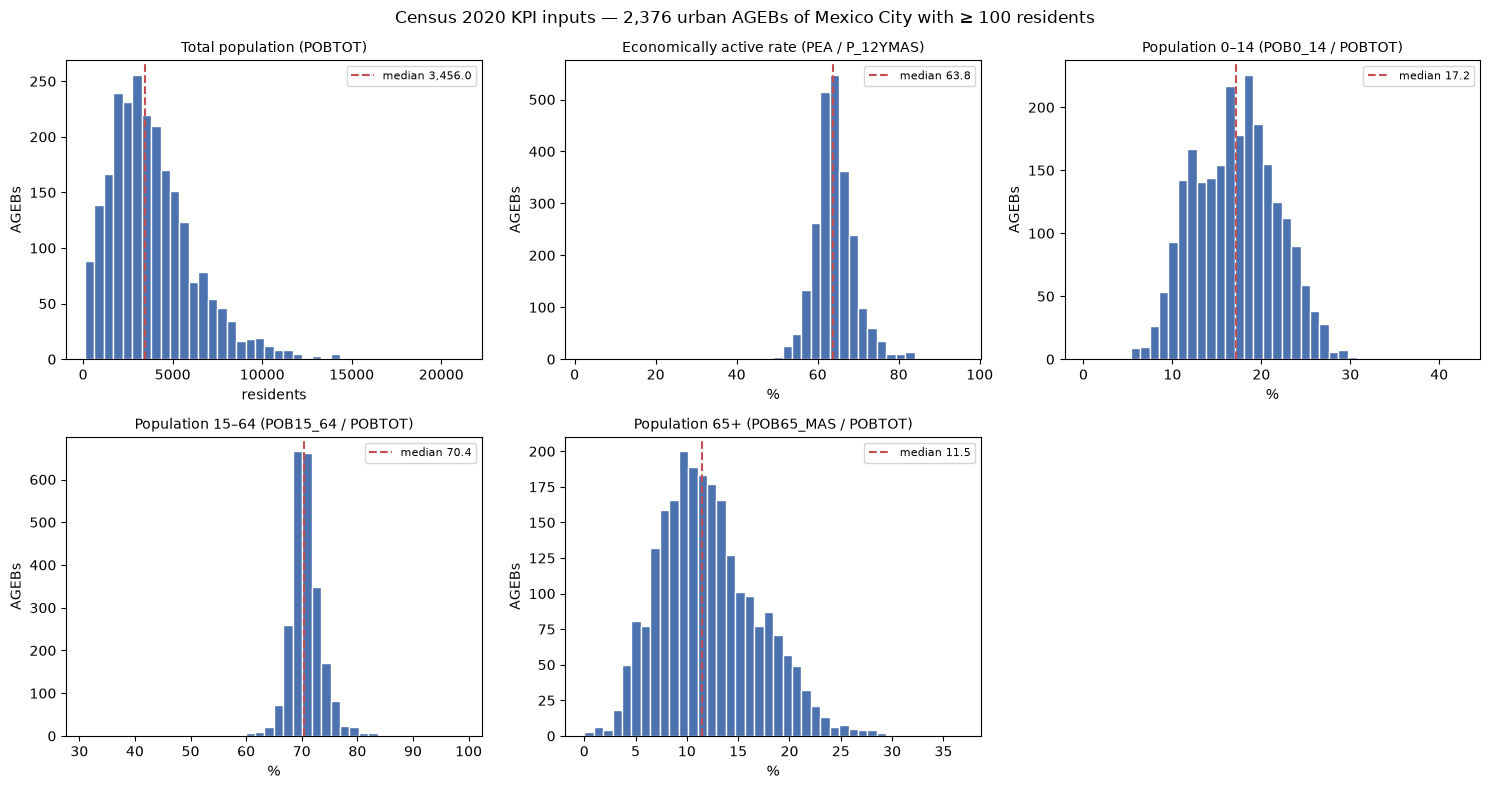

,count,mean,std,min,25%,50%,75%,max,skew
pop_total,2376.0,3845.63,2393.95,107.00,2145.75,3456.00,5036.75,21198.00,1.30
pea_rate,2376.0,64.13,5.19,2.37,61.28,63.76,66.75,95.60,-0.23
pct_0_14,2375.0,17.11,4.70,0.00,13.39,17.15,20.35,42.47,0.12
pct_15_64,2376.0,70.60,3.57,31.03,69.01,70.40,72.02,98.94,-1.48
pct_65_plus,2375.0,12.12,4.81,0.00,8.67,11.52,15.11,36.80,0.55


In [9]:
profiled = urban.loc[~low_population].copy()
profiled_numeric = numeric.loc[profiled.index]
profiled["pea_rate"] = 100 * profiled_numeric["PEA"] / profiled_numeric["P_12YMAS"]
for column, source in [("pct_0_14", "POB0_14"), ("pct_15_64", "POB15_64"), ("pct_65_plus", "POB65_MAS")]:
    profiled[column] = 100 * profiled_numeric[source] / profiled["pop_total"]

panels = [
    ("pop_total", "Total population (POBTOT)", "residents"),
    ("pea_rate", "Economically active rate (PEA / P_12YMAS)", "%"),
    ("pct_0_14", "Population 0–14 (POB0_14 / POBTOT)", "%"),
    ("pct_15_64", "Population 15–64 (POB15_64 / POBTOT)", "%"),
    ("pct_65_plus", "Population 65+ (POB65_MAS / POBTOT)", "%"),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (column, title, unit) in zip(axes.flat, panels):
    data = profiled[column].dropna()
    ax.hist(data, bins=40, color="#4C72B0", edgecolor="white")
    ax.axvline(data.median(), color="#C44E52", linestyle="--", label=f"median {data.median():,.1f}")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(unit)
    ax.set_ylabel("AGEBs")
    ax.legend(fontsize=8)
axes.flat[-1].axis("off")
fig.suptitle(f"Census 2020 KPI inputs — {len(profiled):,} urban AGEBs of Mexico City with ≥ 100 residents", fontsize=12)
fig.tight_layout()
plt.show()

profiled[[column for column, _, _ in panels]].describe().round(2).T.assign(skew=profiled[[c for c, _, _ in panels]].skew().round(2))

- Population per AGEB is right-skewed (skew 1.3, median 3,456, max 21,198), the expected shape for a count over units of unequal size. Densities (population / km²) are computed in the warehouse from the polygon area.
- The PEA rate and the age shares are concentrated around their medians but have long tails (PEA rate from 2 % to 96 %, 15–64 share down to 31 %, skew −1.5). Together with the extreme per-capita values in AGEBs with few residents, this supports **Spearman** correlation and quantile map classes in Phase 3.

## 6. Reconciliation with the state and alcaldía totals

Urban AGEBs do not cover all of Mexico City's population: rural localities in the south (Milpa Alta, Tlalpan, Xochimilco, Tláhuac, Cuajimalpa…) have no AGEB-level results, and two urban AGEBs have no polygon (§2).

In [10]:
state_total = int(census.loc[census["level"].eq("State total"), "POBTOT"].astype(int).iloc[0])
ageb_total = int(ageb["pop_total"].sum())
urban_total = int(urban["pop_total"].sum())

reconciliation = pd.DataFrame(
    {"population": [state_total, -(state_total - ageb_total), ageb_total, -(ageb_total - urban_total), urban_total]},
    index=[
        "State total (MUN='000')",
        "– residents outside urban AGEBs (rural localities)",
        "= all 2,433 census urban AGEBs",
        "– 2 AGEBs without a polygon in 09a.shp",
        "= 2,431 AGEBs loaded into the warehouse",
    ],
)
reconciliation["% of state"] = (100 * reconciliation["population"].abs() / state_total).round(2)

assert state_total == 9_209_944
assert ageb_total == 9_145_632
assert state_total - ageb_total == 64_312
assert urban_total == 9_138_524
reconciliation

,population,% of state
State total (MUN='000'),9209944,100.00
– residents outside urban AGEBs (rural localities),-64312,0.70
"= all 2,433 census urban AGEBs",9145632,99.30
– 2 AGEBs without a polygon in 09a.shp,-7108,0.08
"= 2,431 AGEBs loaded into the warehouse",9138524,99.22


In [11]:
municipality = census.loc[census["level"].eq("Municipality total"), ["MUN", "NOM_MUN", "POBTOT"]].copy()
municipality["alcaldia_total"] = municipality["POBTOT"].astype(int)
ageb["warehouse_pop"] = ageb["pop_total"].where(ageb["has_polygon"], 0)
by_alcaldia = (
    ageb.groupby("MUN")
    .agg(urban_agebs=("has_polygon", "sum"), census_ageb_pop=("pop_total", "sum"), warehouse_pop=("warehouse_pop", "sum"))
    .join(municipality.set_index("MUN")[["NOM_MUN", "alcaldia_total"]])
)
by_alcaldia["rural_pop"] = by_alcaldia["alcaldia_total"] - by_alcaldia["census_ageb_pop"]
by_alcaldia["no_polygon_pop"] = by_alcaldia["census_ageb_pop"] - by_alcaldia["warehouse_pop"]
by_alcaldia["coverage_%"] = (100 * by_alcaldia["warehouse_pop"] / by_alcaldia["alcaldia_total"]).round(2)
by_alcaldia = by_alcaldia[["NOM_MUN", "urban_agebs", "alcaldia_total", "rural_pop", "no_polygon_pop", "warehouse_pop", "coverage_%"]]

assert len(by_alcaldia) == 16
assert by_alcaldia["alcaldia_total"].sum() == state_total
assert by_alcaldia["rural_pop"].sum() == 64_312 and (by_alcaldia["rural_pop"] >= 0).all()
assert by_alcaldia["no_polygon_pop"].sum() == 7_108
assert by_alcaldia["warehouse_pop"].sum() == urban_total
by_alcaldia.sort_values("coverage_%")

,NOM_MUN,urban_agebs,alcaldia_total,rural_pop,no_polygon_pop,warehouse_pop,coverage_%
MUN,,,,,,,
009,Milpa Alta,42,152685,23975,0,128710,84.30
013,Xochimilco,122,442178,12697,0,429481,97.13
012,Tlalpan,207,699928,14369,4058,681501,97.37
011,Tláhuac,110,392313,6992,3050,382271,97.44
004,Cuajimalpa de Morelos,31,217686,4951,0,212735,97.73
008,La Magdalena Contreras,52,247622,1194,0,246428,99.52
010,Álvaro Obregón,199,759137,134,0,759003,99.98
002,Azcapotzalco,103,432205,0,0,432205,100.00
006,Iztacalco,110,404695,0,0,404695,100.00


In [12]:
pea_valid = numeric["PEA"].notna()
print(f"Σ PEA (non-suppressed) = {int(numeric['PEA'].sum()):,}  over {int(pea_valid.sum()):,} AGEBs")
print(f"Σ P_12YMAS             = {int(numeric['P_12YMAS'].sum()):,}")
print(f"Aggregate PEA rate     = {100 * numeric['PEA'].sum() / numeric['P_12YMAS'].sum():.2f} %")
assert int(numeric["PEA"].sum()) == 5_061_682
assert int(numeric["P_12YMAS"].sum()) == 7_858_894

Σ PEA (non-suppressed) = 5,061,682  over 2,421 AGEBs
Σ P_12YMAS             = 7,858,894
Aggregate PEA rate     = 64.41 %


**Why the AGEB population (9,138,524) is not the state total (9,209,944).** The census publishes AGEB results only for *urban* localities. 64,312 residents (0.70 %) live in rural localities, which belong to their alcaldía's total but to no urban AGEB. They are concentrated in the southern alcaldías: Milpa Alta alone has 23,975 rural residents (15.7 % of its population), followed by Tlalpan, Xochimilco and Tláhuac. Nine alcaldías are fully urban. A further 7,108 residents live in the 2 urban AGEBs (Tláhuac and Tlalpan) that have no polygon in the 2020 geostatistical frame and cannot be placed on the map. The warehouse therefore represents **99.2 % of Mexico City's population**, and every KPI describes the urban area, not the whole entity. All reference values of TEAM_PLAN §3.5 are reproduced by the asserts above.